In [140]:
# Data cleaning
import pandas as pd
pd.set_option('display.max_columns', None)

# Reading the dataset
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

display(df.head())
df.info()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [141]:
# Fixing type errors
# errors='coerce' turns the blank spaces (" ") into actual NaN (missing) values.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtype)

float64


In [142]:
# Checking for missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

TotalCharges    11
dtype: int64


In [143]:
# Inspecting missing rows
display(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# Filling missing values with 0 because these customers have no tenure and no charges, indicating they are new customers.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Checking for missing values again
print("Remaining missing values: ", df['TotalCharges'].isnull().sum())

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Remaining missing values:  0


In [144]:
# Detecting true duplicates in the dataset and removing them if any are found
true_duplicates = df.duplicated().sum()
print("Number of true duplicates: ", true_duplicates)

if true_duplicates > 0:
    df = df.drop_duplicates(inplace=True)
    print("True duplicates have been removed.")

# Detecting Coincidental duplicates in the dataset, but not removing them as they may represent different customers with the same information
df.drop(columns=['customerID'], inplace=True)

coincidental_duplicates = df.duplicated().sum()
print("Number of coincidental duplicates: ", coincidental_duplicates)
duplicated_views = df[df.duplicated(keep=False)]
display(duplicated_views.sort_values(by=['tenure', 'MonthlyCharges']).head(6))

Number of true duplicates:  0
Number of coincidental duplicates:  22


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
4817,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.90,No
6706,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,19.90,No


In [145]:
# Exploratory analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style for the plots
sns.set_theme(style="whitegrid", palette="muted")

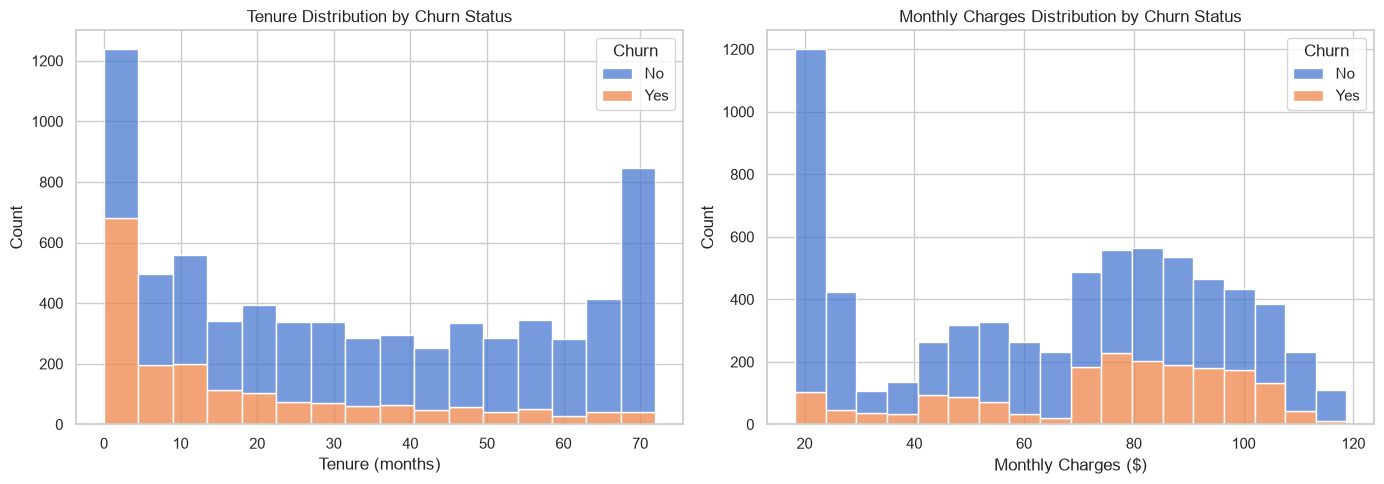

In [146]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Tenure (months)')

# Plot 2: Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn Status')
axes[1].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

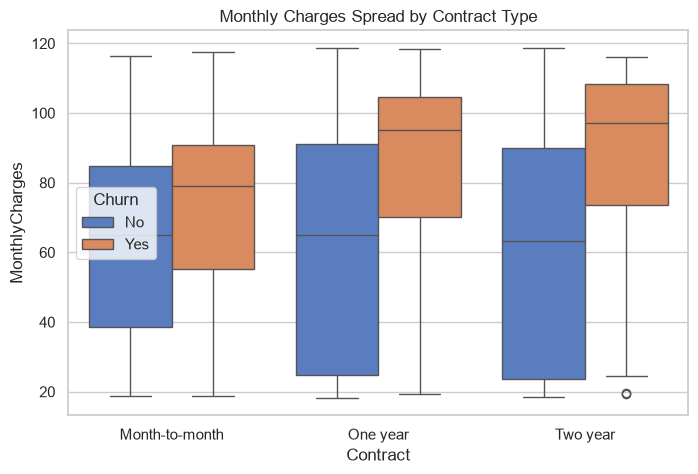

In [147]:
# Boxplots for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn')
plt.title('Monthly Charges Spread by Contract Type')
plt.show()

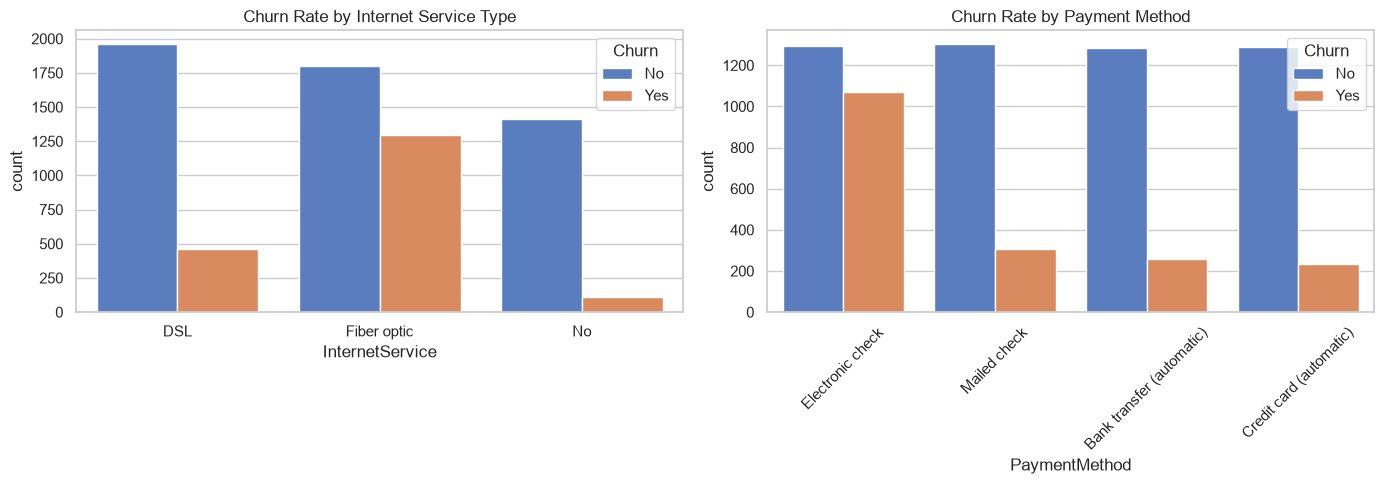

In [148]:
# Feature relationships
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Internet Service vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0])
axes[0].set_title('Churn Rate by Internet Service Type')

# Plot 2: Payment Method vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1])
axes[1].set_title('Churn Rate by Payment Method')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

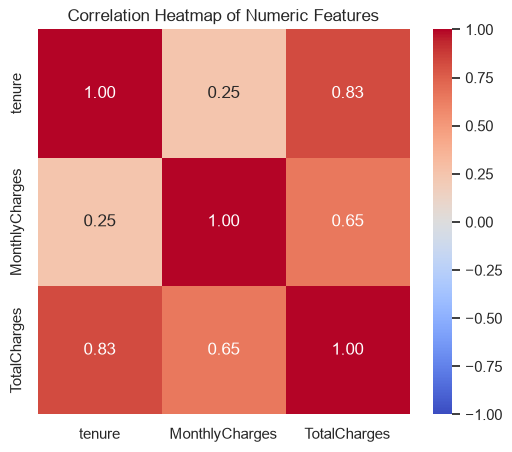

In [149]:
# Correlation heatmap
plt.figure(figsize=(6, 5))

# Selecting only the numeric columns for correlation analysis
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Calculating the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [150]:
# Feature engineering

# Feature 1: Optional services Count (0 - 6) - Count the number of add-on services a customer has subscribed to
optional_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['OptionalServices'] = (df[optional_services] == 'Yes').sum(axis=1)

# Feature 2: High friction warning (0 - 1) - Flag customers paying premium for fiber optic but lacking Tech Support services
df['HighFriction'] = ((df['InternetService'] == 'Fiber optic') & (df['TechSupport'] == 'No')).astype(int)

# Feature 3: Loyal but still paying monthly charges (0 - 1) - Flag long-term customers (tenure > 24 months) who are still paying monthly charges
df['LoyalMonthlyPayer'] = ((df['tenure'] > 24) & (df['Contract'] == 'Month-to-month')).astype(int)

display(df[['OptionalServices', 'HighFriction', 'LoyalMonthlyPayer']].head(9))

,OptionalServices,HighFriction,LoyalMonthlyPayer
0,1,0,0
1,2,0,0
2,2,0,0
3,3,0,0
4,0,1,0
5,3,1,0
6,2,1,0
7,1,0,0
8,4,0,1


In [151]:
# Encode Categorical Variables

#Checking to see how many unique values are in each column
for col in df.select_dtypes(include=['object']).columns:
    unique_count = df[col].nunique()
    unique_values = df[col].unique()
    print(f"Column: {col} | Options: {unique_count} | Unique Values: {unique_values}")

Column: gender | Options: 2 | Unique Values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Column: Partner | Options: 2 | Unique Values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Column: Dependents | Options: 2 | Unique Values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Column: PhoneService | Options: 2 | Unique Values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Column: MultipleLines | Options: 3 | Unique Values: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Column: InternetService | Options: 3 | Unique Values: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Column: OnlineSecurity | Options: 3 | Unique Values: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Column: OnlineBackup | Options: 3 | Unique Values: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Column: DeviceProtection | Options: 3 | Unique Values: <StringArray>
['No', 'Yes', 'No internet service']
Length:

C:\Users\Clopo\AppData\Local\Temp\ipykernel_6588\614822685.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [152]:
# Binary encoding for column with only two options
binary_mapping = {'Yes': 1, 'No': 0}
df['Churn'] = df['Churn'].map(binary_mapping)
df['PaperlessBilling'] = df['PaperlessBilling'].map(binary_mapping)
df['PhoneService'] = df['PhoneService'].map(binary_mapping)
df['Partner'] = df['Partner'].map(binary_mapping)
df['Dependents'] = df['Dependents'].map(binary_mapping)

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# One-hot encoding for columns with more than two options
multi_option_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_option_columns, drop_first=True)

# Displaying the first few rows of the cleaned and encoded dataset
display(df.head())
df.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,OptionalServices,HighFriction,LoyalMonthlyPayer,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,2,0,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,2,0,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,3,0,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,0,1,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  OptionalServices                       7043 non-null   int64  
 11  HighFriction   

In [153]:
# Normalize numeric features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_features] = scaler.fit_transform(df[numeric_features])

display(df[numeric_features].head())

,tenure,MonthlyCharges,TotalCharges
0,0.013889,0.115423,0.003437
1,0.472222,0.385075,0.217564
2,0.027778,0.354229,0.012453
3,0.625000,0.239303,0.211951
4,0.027778,0.521891,0.017462


ACTIONABLE FINDINGS:

    1. Implement a 90-day onboarding program
    DATA: The tenure distribution plot revealed that there is a massive spike in churn between months 0 and 5.

    ACTION: Clients are experiencing "buyer's remorse" or tehnical frustration immeadiately after signing up. We must deploy an automatic check-in system (calls or targeted emails) during the first 3 months to resolve tehnical isssues before client decides to cancel. 

    2. Change Fiber Optic infrastructure and pricing
    DATA: The churn rate by Inernet Service type plot reveals that Fiber Optic clients churn at a way higher rate than DSL clients.

    ACTION: Fiber should be a better service than DSL. The fact that the churn rate is so high means that the current price does not match the quality of the product or maybe it is overpriced.

    3. Make automatic payments more comfortable, appealing.
    DATA: The churn rate by method plot reveals that clients paying via "Electronic Check" churn at a very high volume compared to those using automatic alternatives.

    ACTION: Paying manually every month forces clients to actively ask themselves if the service is worth it. Automatic payments remove this friction. Make the automatic options stand out more or offer small discounts to those who switch from Electronic Check to automatic pay.

    4. Introduce "Mid-tier" pricing interventions.
    DATA: Both our histogram and boxplot show us that monthly charges over $70 lead to high churn rates.

    ACTION: When a high-paying customer calls to cancel, offer the a customized "mid-tier" bundle (~$60) rather than losing them entirely.

    5. Target Month-to-month contract conversions at the 6-month mark.
    DATA: The boxplot confirmed that month-to-month contracts are unstable. However the tenure chart showed that if a client survives past the 6 month mark the likelyhood of churning drops significantly.

    ACTION: Send an exclusive, targeted promotion to month-to-month customers exactly on their 6 month, offering them better prices if they sign a 1-year contract.

POTENTIAL DATA LEAKAGE:

tenure and TotalCharges columns.

Problem: The ML model will flag every new customer as a big churn risk because they didn't have the time to increase the TotalCharges number.

Fix: Drop the TotalCharges column before training a model.

In [154]:
# Export cleaned dataset
df_final = df.drop(columns=['TotalCharges'])

df_final.to_csv('cleaned_dataset.csv', index=False)